# Notebook 01: Problem Statement & Exploratory Data Analysis

**Student Name:** [Your Name]

**Dataset:** [Your Dataset Name]

**Checkpoints:**
- Checkpoint 1 (Due Feb 1): Sections 1-3
- Checkpoint 2 (Due Feb 8): Sections 4-6

---

## Rules & Integrity

1. **NO AI TOOLS**: You may **NOT** use ChatGPT, Claude, Gemini, GitHub Copilot, or any other AI assistant to generate code for this assignment. The goal is to build *your* fundamental skills. If you rely on AI now, the advanced topics later will be impossible.

2. **Study Groups Encouraged**: You **ARE** encouraged to discuss ideas, share approaches, and explain concepts to your study group peers. Teaching others is the best way to learn! However, the code you submit must be **your own work**.

3. **Use Your Resources**: You are free to use Google, StackOverflow, Pandas/Scikit-learn documentation, and your class notes.

4. **Comment Your Code**: Include comments explaining *why* you're doing what you're doing. I want to see your thought process.

5. **Resubmission**: You may submit this assignment multiple times for feedback before each checkpoint deadline.

---

## Important: Written Reflections

Throughout this notebook, you'll see text cells asking you to explain your decisions, observations, and reasoning. **These written reflections are a critical part of your grade.** 

Don't just write one-word answers or skip these sections. Your reflections demonstrate:
- Your understanding of the data science process
- Your ability to communicate findings to stakeholders
- Your critical thinking about data quality and feature importance

Take time to write thoughtful, complete responses. This is what separates a good data scientist from someone who just runs code!

---

## Setup

Run this cell first to import all necessary libraries.

In [1]:
# Core libraries
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')

# Ignore warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

print("Libraries imported successfully!")

Libraries imported successfully!


---

# CHECKPOINT 1 (Due: Feb 1)

---

## Section 1: Problem Statement

### 1.1 What are you trying to predict?

*Clearly state your target variable and what it represents.*

**Your answer:**

[The goal of this project is to predict the stage of Chronic Kidney Disease (CKD) for each patient using the medical features provided in the dataset. The CKD stage represents how well a patient’s kidneys are functioning based on their lab results and health indicators)

---

### 1.2 Why does this prediction matter?

*Who would care about this prediction? What decisions could be made with it?*

**Your answer:**

[Predicting the CKD stage is important because it helps determine how severe a patient’s kidney condition is. This information can assist doctors in making decisions about treatment plans, monitoring strategies, and early interventions to prevent further kidney damage.)

---

### 1.3 What features might help predict the target?

*Based on your intuition and domain knowledge, what columns do you think will be most important?*

**Your answer:**

[GFR is the primary indicator of kidney function,but several other features in the dataset can help predict CKD stage. These include serum creatinine, blood urea nitrogen (BUN), protein in urine, potassium levels, blood pressure, age, and glucose levels. These features are important because they either directly measure how well the kidneys filter waste or show how the body is affected when kidney function declines.)

## Section 2: Dataset Overview

### 2.1 Load Your Data

In [23]:
# Load your dataset
# Update the path to match your file name
df = pd.read_csv('../data/raw/kidney_dataset.csv')

# Display basic info
print(f"Dataset shape: {df.shape[0]:,} rows, {df.shape[1]} columns")
print(f"\nColumn names:")
print(df.columns.tolist())

Dataset shape: 5,000 rows, 11 columns

Column names:
['Creatinine', 'BUN', 'GFR', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Medication', 'CKD_Status']


In [ ]:
# In order for me to provide the stages numerically, I had to add the code below based on the GFR number. 

def determine_ckd_stage(gfr):
    if gfr >= 90:
        return 1
    elif gfr >= 60:
        return 2
    elif gfr >= 30:
        return 3
    elif gfr >= 15:
        return 4
    else:
        return 5

df["CKD Stage"] = df["GFR"].apply(determine_ckd_stage)

# Re-run the code to drop this from the beginning to help with the leakage, I learned the ignore from Google for the errors. 

df = df.drop(columns=["GFR", "CKD_Status", "Medication"], errors="ignore")


In [26]:
# TODO: View the first 5 rows of your dataframe
#
# Hint: Use .head()

# YOUR CODE HERE: 
df.head()


,Creatinine,BUN,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,CKD Stage
0,0.788803,8.386869,1632.649387,0,0,27.682074,106.700203,1.570370,1
1,3.413970,53.688796,935.540516,1,0,33.122208,410.008362,3.425287,3
2,0.647645,7.466540,1774.553846,1,1,55.832284,123.336925,1.123301,2
3,0.795508,12.516821,2360.602980,0,0,32.391900,116.098870,3.086846,1
4,0.869010,19.855960,1987.750901,0,1,66.689515,55.668760,2.174980,2


In [27]:
# TODO: View the last 5 rows of your dataframe
#
# Hint: Use .tail()

# YOUR CODE HERE:
df.tail()


,Creatinine,BUN,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,CKD Stage
4995,4.048737,53.094020,1179.120228,1,1,64.910042,2846.781763,3.403640,4
4996,0.787392,7.598859,2029.623102,0,1,49.365980,56.600073,1.759214,1
4997,1.177967,10.198228,2463.843638,0,1,47.207777,88.090385,2.238708,2
4998,1.189794,12.446732,1851.314122,1,0,31.270049,64.837267,3.188672,1
4999,1.000078,11.804883,2056.462819,0,0,61.782239,134.514375,3.755283,1


### 2.2 Data Types and Info

In [28]:
# TODO: Display info about your dataframe (data types, non-null counts)
#
# Hint: Use .info()

# YOUR CODE HERE:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Creatinine        5000 non-null   float64
 1   BUN               5000 non-null   float64
 2   Urine_Output      5000 non-null   float64
 3   Diabetes          5000 non-null   int64  
 4   Hypertension      5000 non-null   int64  
 5   Age               5000 non-null   float64
 6   Protein_in_Urine  5000 non-null   float64
 7   Water_Intake      5000 non-null   float64
 8   CKD Stage         5000 non-null   int64  
dtypes: float64(6), int64(3)
memory usage: 351.7 KB


In [29]:
# TODO: Get summary statistics for numerical columns
#
# Hint: Use .describe()

# YOUR CODE HERE:
df.describe()

,Creatinine,BUN,Urine_Output,Diabetes,Hypertension,Age,Protein_in_Urine,Water_Intake,CKD Stage
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,1.994088,30.780063,1664.302800,0.294000,0.378200,50.048733,537.053851,2.504335,2.073200
std,2.027013,31.148341,599.384655,0.455637,0.484986,14.492020,817.510451,0.868925,1.359489
min,0.600040,7.007732,400.502554,0.000000,0.000000,18.000000,50.010471,1.000810,1.000000
25%,0.801333,11.367599,1105.890821,0.000000,0.000000,40.190016,83.692533,1.744138,1.000000
50%,1.007629,15.878566,1814.499690,0.000000,0.000000,49.942824,119.492591,2.511710,2.000000
75%,2.163997,40.636666,2146.441778,1.000000,1.000000,59.761132,588.428649,3.268812,3.000000
max,7.996428,119.931652,2499.939696,1.000000,1.000000,90.000000,2997.724192,3.998043,5.000000


In [31]:
# TODO: Get summary statistics for categorical columns
#
# Hint: Use .describe(include='object')

# YOUR CODE HERE:

# I had to edit the original code, since I cleaned up the columns ahead while I re-do step by step which is now showing different results this time around
cat_cols = df.select_dtypes(include=['object', 'category']).columns

if len(cat_cols) > 0:
    print(df[cat_cols].describe())
else:
    print("No categorical columns remaining in dataset.")


No categorical columns remaining in dataset.


### 2.3 Dataset Description

*After looking at the data above, describe your dataset in your own words.*

**Questions to answer:**
- Where did this data come from? (Kaggle link, source)
- What does each row represent?
- How many features do you have?
- What types of features do you have? (numerical, categorical)

**Your description:**

[This dataset is from Kaggle website. Each row represents a patient with a total of 12 features. After reviewing the data, it has all numerical, but 1 column (Medication) that is categorical]

## Section 3: Initial EDA

### 3.1 Target Variable Analysis

In [32]:
# Define your target variable
TARGET = 'CKD Stage'  # <-- UPDATE THIS!

# Basic statistics of target
print(f"Target Variable: {TARGET}")
print(f"\nBasic Statistics:")
print(df[TARGET].describe())

Target Variable: CKD Stage

Basic Statistics:
count    5000.000000
mean        2.073200
std         1.359489
min         1.000000
25%         1.000000
50%         2.000000
75%         3.000000
max         5.000000
Name: CKD Stage, dtype: float64


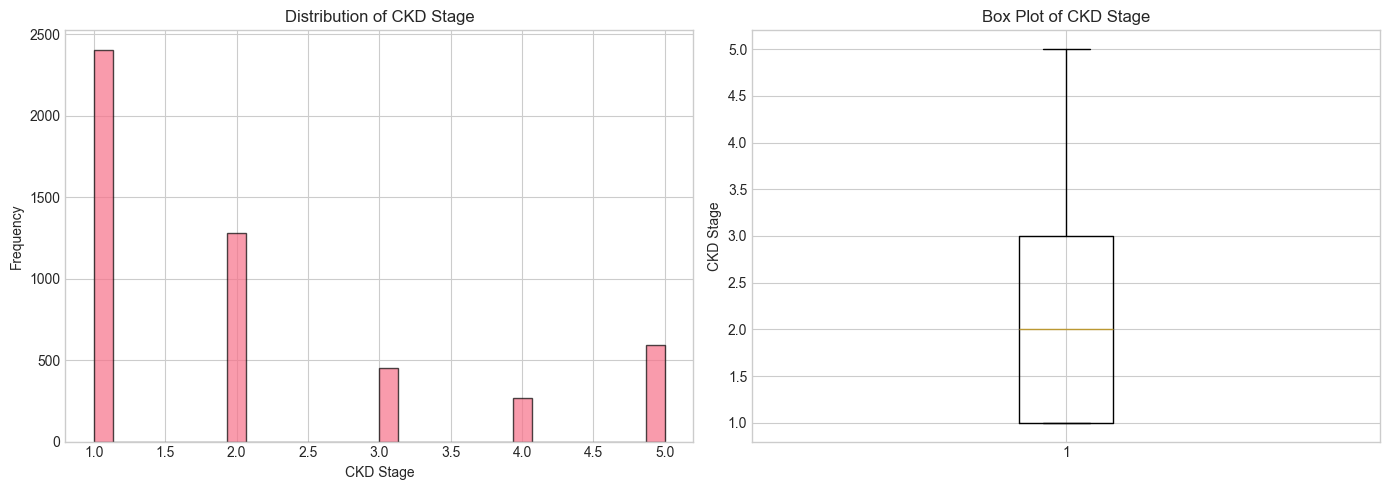


Skewness: 1.13
→ Target is highly skewed. Consider log transform in feature engineering.


In [34]:
# Distribution of target variable
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histogram
axes[0].hist(df[TARGET].dropna(), bins=30, edgecolor='black', alpha=0.7)
axes[0].set_xlabel(TARGET)
axes[0].set_ylabel('Frequency')
axes[0].set_title(f'Distribution of {TARGET}')

# Box plot
axes[1].boxplot(df[TARGET].dropna())
axes[1].set_ylabel(TARGET)
axes[1].set_title(f'Box Plot of {TARGET}')

plt.tight_layout()
plt.show()

# Check skewness
skewness = df[TARGET].skew()
print(f"\nSkewness: {skewness:.2f}")
if abs(skewness) > 1:
    print("→ Target is highly skewed. Consider log transform in feature engineering.")
elif abs(skewness) > 0.5:
    print("→ Target is moderately skewed.")
else:
    print("→ Target is approximately symmetric.")

### 3.2 Data Quality Checks

In [35]:
# TODO: Check for duplicate rows in your dataframe
#
# Steps:
# 1. Count how many duplicate rows exist using df.duplicated().sum()
# 2. Print the count and the percentage of duplicates
#
# Expected output format:
# "Duplicate rows: X,XXX (X.XX%)"

# YOUR CODE HERE:
duplicate_count = df.duplicated().sum()
duplicate_percent = (duplicate_count/ len(df))*100

print(f"Duplicate rows: {duplicate_count} ({duplicate_percent:.2f}%)")



Duplicate rows: 0 (0.00%)


In [36]:
# TODO: Create a summary of missing values
#
# Steps:
# 1. Calculate missing count for each column: df.isnull().sum()
# 2. Calculate missing percentage: (df.isnull().sum() / len(df)) * 100
# 3. Create a DataFrame with 'Missing Count' and 'Missing %' columns
# 4. Sort by 'Missing %' descending
# 5. Display only columns that have missing values
#
# Hint: You can create a DataFrame with pd.DataFrame({'col1': series1, 'col2': series2})

# YOUR CODE HERE:

# Calculate missing count and percentage
missing_count = df.isnull().sum()
missing_percent = (missing_count / len(df)) * 100

# Create a summary DataFrame
missing_summary = pd.DataFrame({
    "Missing Count": missing_count,
    "Missing %": missing_percent
})

# Sort by highest missing %
missing_summary = missing_summary.sort_values(by="Missing %", ascending=False)

# Show only the columns with missing values
missing_summary[missing_summary["Missing Count"] > 0]



,Missing Count,Missing %


In [37]:
# Visualize missing values (if any)
if df.isnull().sum().sum() > 0:
    plt.figure(figsize=(12, 6))
    missing_cols = missing_summary[missing_summary['Missing Count'] > 0]
    colors = ['red' if pct > 50 else 'orange' if pct > 20 else 'steelblue' 
              for pct in missing_cols['Missing %']]
    plt.barh(missing_cols.index, missing_cols['Missing %'], color=colors)
    plt.xlabel('Missing Percentage')
    plt.title('Missing Values by Column')
    plt.axvline(x=50, color='red', linestyle='--', alpha=0.5, label='50% threshold')
    plt.legend()
    plt.tight_layout()
    plt.show()
    
    # Recommendation
    high_missing = missing_cols[missing_cols['Missing %'] > 50]
    if len(high_missing) > 0:
        print(f"\n⚠️ Columns with >50% missing (consider dropping): {high_missing.index.tolist()}")
else:
    print("✓ No missing values in the dataset!")

✓ No missing values in the dataset!


### 3.3 Initial Observations

*Based on your initial exploration, what do you notice?*

**Questions to consider:**
- Is your target variable normally distributed or skewed?
- Are there any obvious outliers in the target?
- How much missing data do you have to deal with?
- Are there any duplicate rows?
- Any surprises or interesting findings?

**Your observations:**

[The target variable CKD Stage is skewed toward the lower stages (Healthy Patients) since many are in Stage 1 and 2. There was less patients in Stages 3, 4, and 5. This indicates that the dataset is a bit imbalanced with having more early stages of CKD than severe cases (Stage 4 & 5). Addtionally, there are no duplicates rows in this dataset, which means that each row represents a unique patient record. Further evaluating the dataset, I noticed that the 'Mediation' column/feature contains more than 50% missing values. However, this is not an important feature for my target variable right now, and would need to remove this columnn/feature in the coming checkpoints/lessons for this capstone. What I did find interesting, is this dataset contains majority numerical data, and did not require heavy cleaning or conversion. This means this is very good for a Machine Learning/AI Model after handling the Medication column/feature removal soon. ]

---

## ✅ Checkpoint 1 Submission Instructions

**Congratulations!** You've completed Checkpoint 1. Before moving on, let's commit your work and submit.

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub
Open your terminal and run these commands:

```bash
# Navigate to your project folder (if not already there)
cd path/to/your/capstone-project

# Stage your notebook and data
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/raw/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 1: Problem statement and initial EDA"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 1 assignment on Canvas
2. Submit the link to your GitHub repository
3. Make sure your repo shows your latest commit!

### Step 4: Continue to Checkpoint 2
Now proceed to **Section 4** below to continue with your complete EDA, data cleaning, and feature engineering.

---

---

# CHECKPOINT 2 (Due: Feb 8)

---

## Section 4: Complete EDA

### 4.1 Numerical Features Analysis

In [38]:
# TODO: Get a list of numerical columns (excluding the target)
#
# Steps:
# 1. Use df.select_dtypes(include=[np.number]) to get numerical columns
# 2. Get the column names as a list with .columns.tolist()
# 3. Remove TARGET from the list if it's in there
# 4. Print the count and list of numerical features
#
# Store result in: numerical_cols

# YOUR CODE HERE:

# Get list of numerical columns / Used Google to help me remember this part
numerical_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Removing the target column
if TARGET in numerical_cols:
    numerical_cols.remove(TARGET)

# Remove leakage columns from the dataset
for col_to_remove in ['CKD_Status', 'GFR', 'Low_GFR']:
    if col_to_remove in numerical_cols:
        numerical_cols.remove(col_to_remove)

# Removed CKD_Status, since I want to pay attention to only CKD Stage that I added in Checkpoint 1
if "CKD_Status" in numerical_cols:
    numerical_cols.remove("CKD_Status")


# Print results to reflect how many features & Column names with numerical texts
print(f"Number of numerical features: {len(numerical_cols)}")
print("Numerical columns:")
print(numerical_cols)



Number of numerical features: 8
Numerical columns:
['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake']


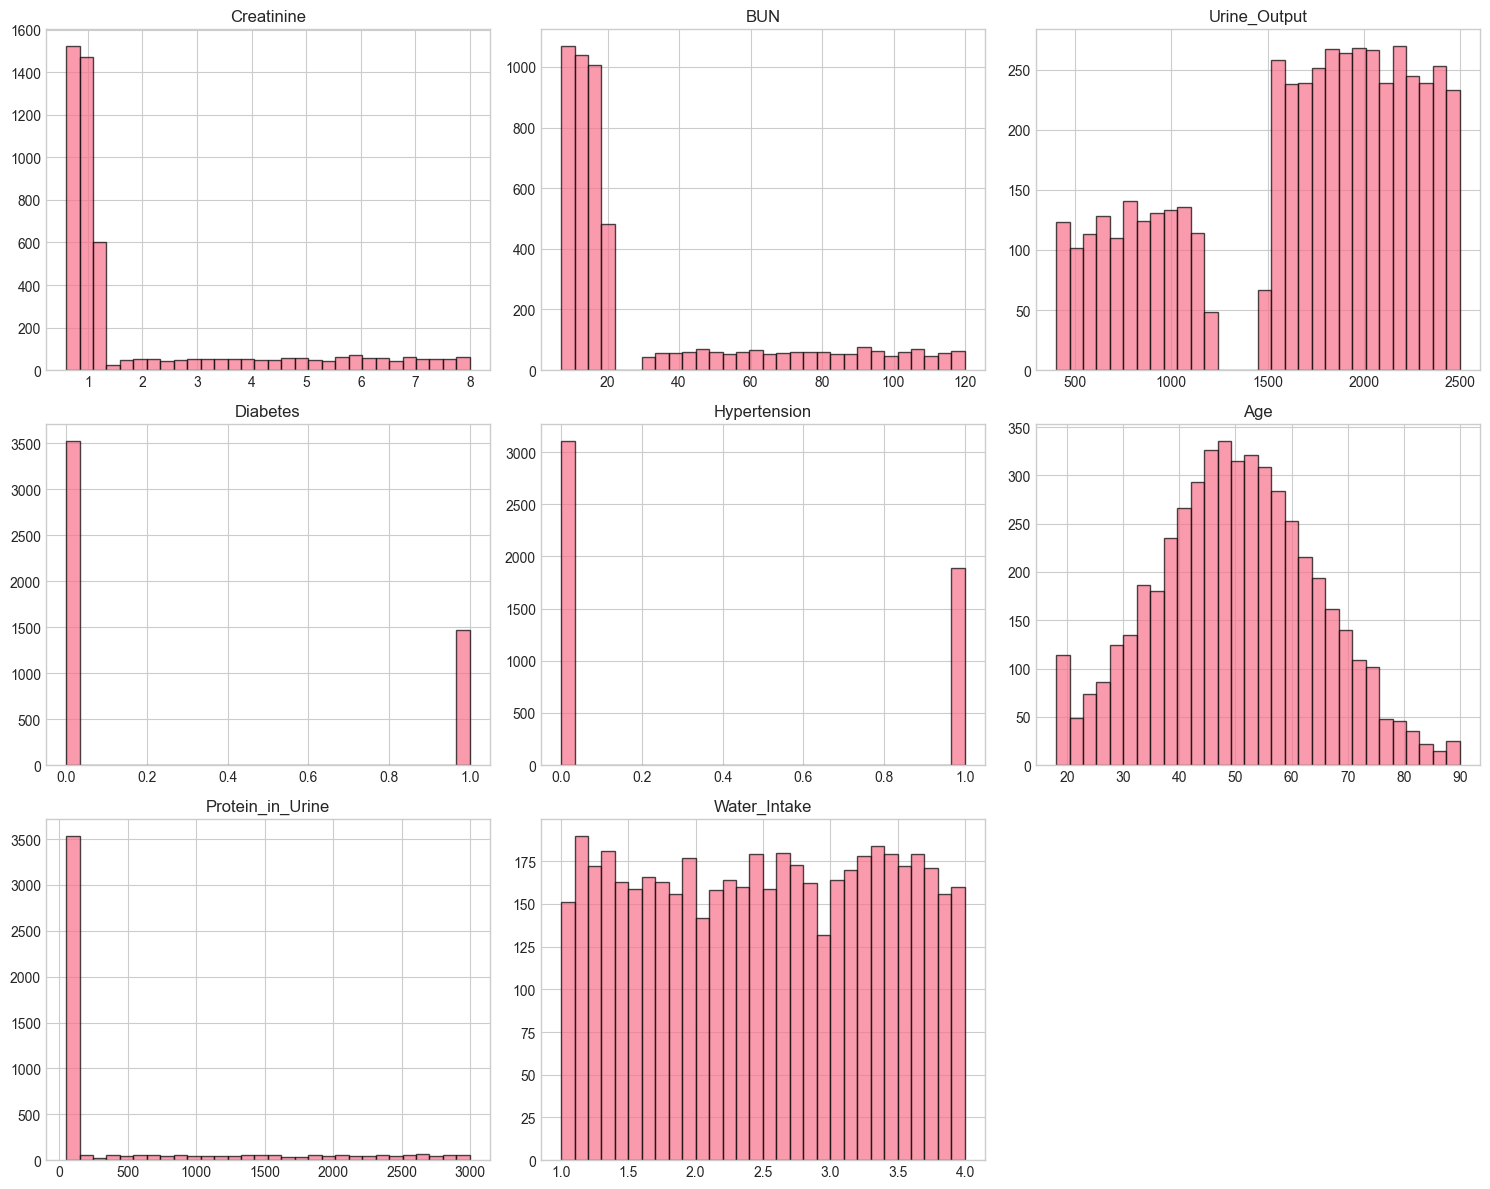

In [39]:
# Distribution of numerical features
if len(numerical_cols) > 0:
    n_cols = 3
    n_rows = (len(numerical_cols) + n_cols - 1) // n_cols

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if n_rows == 1 and n_cols == 1 else axes

    for i, col in enumerate(numerical_cols):
        axes[i].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
        axes[i].set_title(col)
        axes[i].set_xlabel('')

    # Hide empty subplots
    for j in range(len(numerical_cols), len(axes)):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features found (besides target).")

### 4.2 Categorical Features Analysis

In [40]:
# TODO: Get a list of categorical columns and explore their values
#
# Steps:
# 1. Use df.select_dtypes(include=['object', 'category']) to get categorical columns
# 2. Get the column names as a list
# 3. Print the count and list of categorical features
# 4. For each categorical column, print:
#    - Number of unique values: df[col].nunique()
#    - Top 10 value counts: df[col].value_counts().head(10)
#
# Store result in: categorical_cols

# YOUR CODE HERE:

# Get list of categorical columns
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print count and names
print(f"Number of categorical features: {len(categorical_cols)}")
print("Categorical columns:")
print(categorical_cols)

# Explore values in each categorical column
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Top value counts:")
    print(df[col].value_counts().head(10))



Number of categorical features: 0
Categorical columns:
[]


In [41]:
# Retesting the list of categorical columns to ensure it's removed
categorical_cols = df.select_dtypes(include=['object', 'category']).columns.tolist()

# Print count and names, if still there
print(f"Number of categorical features: {len(categorical_cols)}")
print("Categorical columns:")
print(categorical_cols)

# Explore values in each categorical column, if still there
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print(f"Number of unique values: {df[col].nunique()}")
    print("Top value counts:")
    print(df[col].value_counts().head(10))

Number of categorical features: 0
Categorical columns:
[]


In [42]:
# Visualize categorical features (for columns with reasonable number of categories)
cat_cols_to_plot = [col for col in categorical_cols if df[col].nunique() <= 10]

if cat_cols_to_plot:
    n_cols = 2
    n_rows = (len(cat_cols_to_plot) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(14, 4*n_rows))
    axes = axes.flatten() if n_rows > 1 else [axes] if len(cat_cols_to_plot) == 1 else axes
    
    for i, col in enumerate(cat_cols_to_plot):
        df[col].value_counts().plot(kind='bar', ax=axes[i], edgecolor='black')
        axes[i].set_title(col)
        axes[i].set_xlabel('')
        axes[i].tick_params(axis='x', rotation=45)
    
    # Hide empty subplots
    for j in range(len(cat_cols_to_plot), len(axes)):
        axes[j].set_visible(False)
    
    plt.tight_layout()
    plt.show()
else:
    print("No categorical columns with ≤10 unique values to plot.")

No categorical columns with ≤10 unique values to plot.


### 4.3 Categorical Features vs Target

*How does the target variable differ across categories?*

In [43]:
# Box plots: Target by categorical features
cat_cols_to_analyze = [col for col in categorical_cols if df[col].nunique() <= 8]

if cat_cols_to_analyze:
    for col in cat_cols_to_analyze[:4]:  # Limit to first 4 for readability
        plt.figure(figsize=(12, 5))
        
        # Order by median target value
        order = df.groupby(col)[TARGET].median().sort_values().index
        
        sns.boxplot(data=df, x=col, y=TARGET, order=order)
        plt.title(f'{TARGET} by {col}')
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()
        
        # Show mean target by category
        print(f"\nMean {TARGET} by {col}:")
        print(df.groupby(col)[TARGET].agg(['mean', 'median', 'count']).sort_values('mean', ascending=False))
        print("\n" + "="*50)
else:
    print("No suitable categorical columns for this analysis.")

No suitable categorical columns for this analysis.


### 4.4 Correlation Analysis

In [44]:
# Before doing the following, I wanted to make all those features are still removed as I work down this code 

print(df.columns)


Index(['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age',
       'Protein_in_Urine', 'Water_Intake', 'CKD Stage'],
      dtype='object')


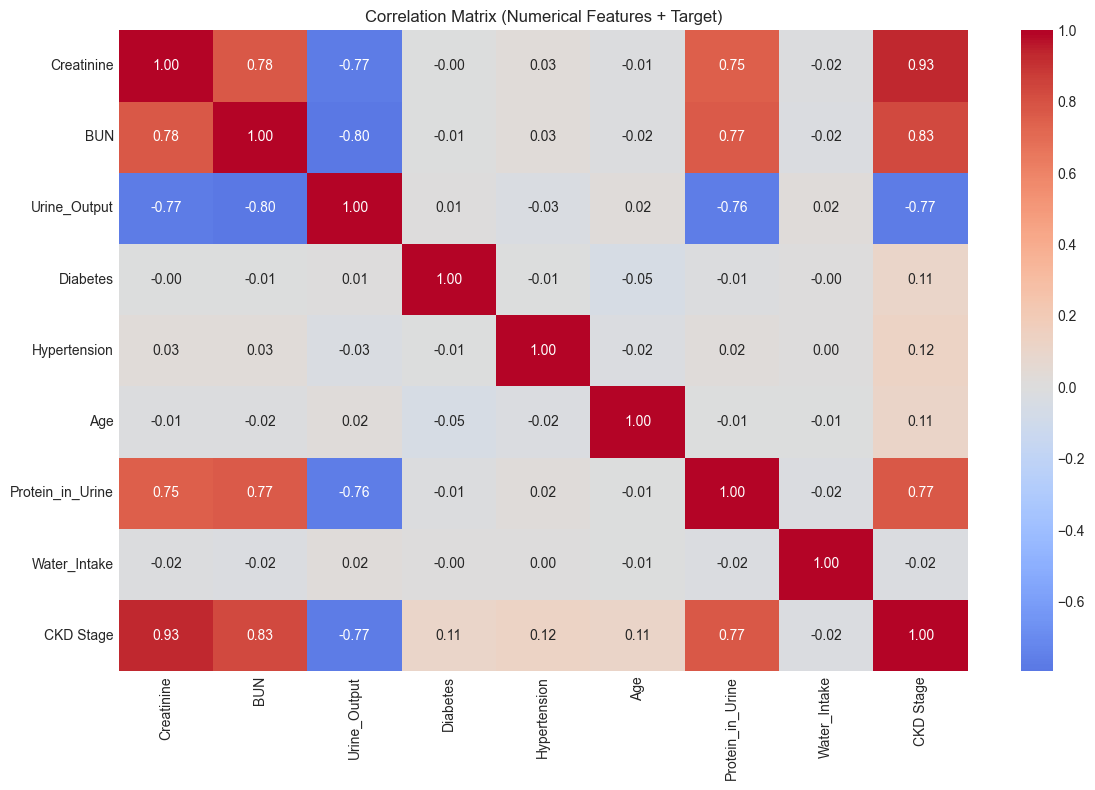

In [45]:
# TODO: Create and visualize a correlation matrix
#
# Steps:
# 1. Create a list of columns: numerical_cols + [TARGET]
# 2. Calculate the correlation matrix: df[columns].corr()
# 3. Create a heatmap using sns.heatmap()
#
# Heatmap parameters to use:
# - annot=True (show numbers)
# - cmap='coolwarm' (color scheme)
# - center=0 (center colormap at 0)
# - fmt='.2f' (2 decimal places)
#
# Store the correlation matrix in: correlation_matrix

# YOUR CODE HERE:

# Step 1: Create list of columns for correlation matrix 
cols_for_corr = numerical_cols + [TARGET]

# Step 2: Calculate correlation matrix / Used Google for this section
correlation_matrix = df[cols_for_corr].corr()

# Step 3: Plot heatmap / I referenced our previous assignments for this section, took me a bit honestly
plt.figure(figsize=(12, 8))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    center=0,
    fmt=".2f"
)

plt.title("Correlation Matrix (Numerical Features + Target)")
plt.tight_layout()
plt.show()



In [46]:
# TODO: Extract and analyze correlations with the target variable
#
# Steps:
# 1. Get the TARGET column from correlation_matrix
# 2. Drop the TARGET's correlation with itself (it's always 1.0)
# 3. Sort values in descending order
# 4. Print the correlations
# 5. Identify strong correlations (absolute value > 0.5)
#
# Store result in: target_correlations

# YOUR CODE HERE:

# 1) Get correlations with the target variable / Used both our previous assignments and Google for this section
target_correlations = correlation_matrix[TARGET]

# 2) Remove the target's correlation with itself (always 1.0)
target_correlations = target_correlations.drop(TARGET)

# 3) Sorting the values from strongest to weakest correlation
target_correlations = target_correlations.sort_values(ascending=False)

# 4) Print all correlations for results
print("Correlations with CKD Stage:")
print(target_correlations)

# 5) Identify strong correlations (absolute value > 0.5) 
strong_correlations = target_correlations[abs(target_correlations) > 0.5]

print("\nStrong correlations (|correlation| > 0.5):")
print(strong_correlations)


Correlations with CKD Stage:
Creatinine          0.934905
BUN                 0.827796
Protein_in_Urine    0.770423
Hypertension        0.124568
Age                 0.113752
Diabetes            0.105729
Water_Intake       -0.018591
Urine_Output       -0.774109
Name: CKD Stage, dtype: float64

Strong correlations (|correlation| > 0.5):
Creatinine          0.934905
BUN                 0.827796
Protein_in_Urine    0.770423
Urine_Output       -0.774109
Name: CKD Stage, dtype: float64


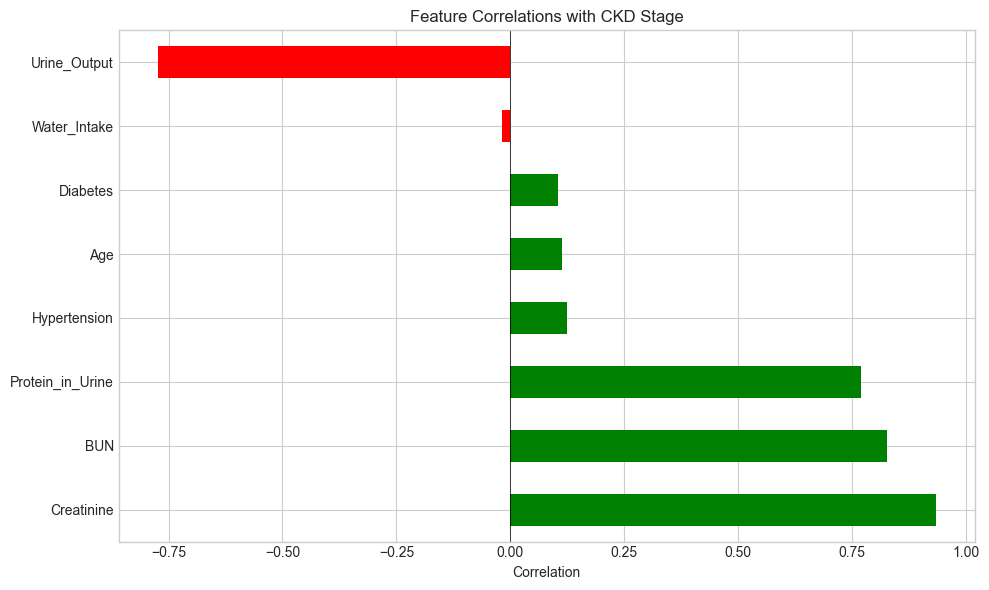

In [47]:
# Visualize correlations with target
plt.figure(figsize=(10, 6))
colors = ['green' if c > 0 else 'red' for c in target_correlations]
target_correlations.plot(kind='barh', color=colors)
plt.xlabel('Correlation')
plt.title(f'Feature Correlations with {TARGET}')
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.show()

### 4.5 Feature vs Target Relationships

*Create scatter plots for your most promising numerical features against the target.*

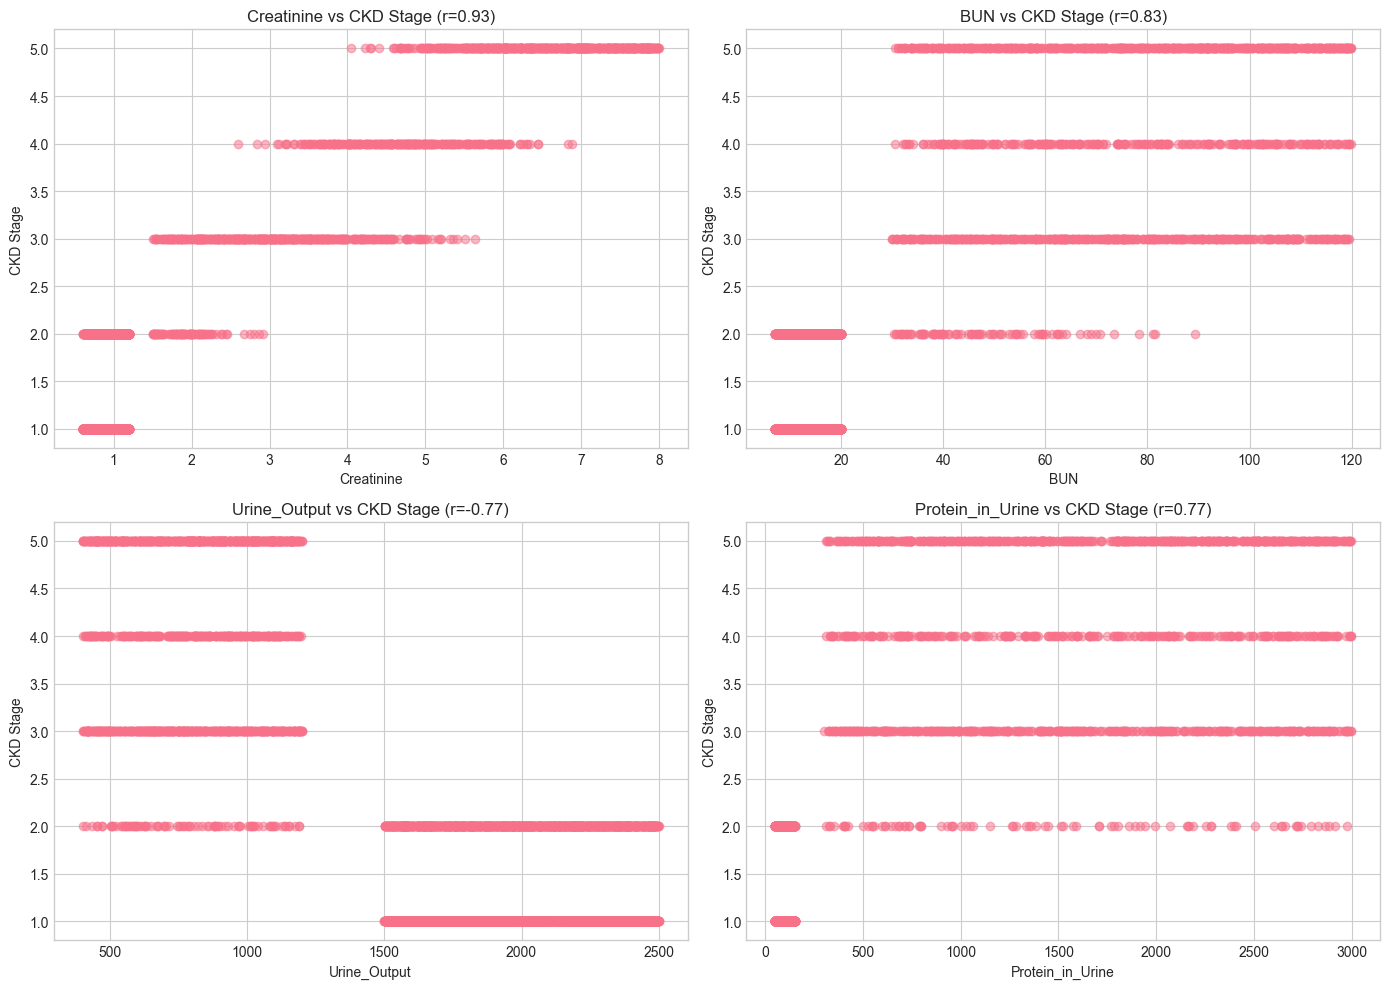

In [48]:
# Select top correlated features to plot
top_features = target_correlations.abs().sort_values(ascending=False).head(4).index.tolist()

if len(top_features) > 0:
    n_features = min(4, len(top_features))
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    axes = axes.flatten()

    for i, feature in enumerate(top_features[:n_features]):
        axes[i].scatter(df[feature], df[TARGET], alpha=0.5)
        axes[i].set_xlabel(feature)
        axes[i].set_ylabel(TARGET)
        corr = df[feature].corr(df[TARGET])
        axes[i].set_title(f'{feature} vs {TARGET} (r={corr:.2f})')

    # Hide unused subplots
    for j in range(n_features, 4):
        axes[j].set_visible(False)

    plt.tight_layout()
    plt.show()
else:
    print("No numerical features to plot.")

### 4.6 Additional Exploration (Your Choice!)

The sections above provide a foundation, but every dataset is unique. Use the cells below to explore additional aspects of YOUR data that you think are important.

**Ideas for additional exploration:**
- Violin plots for categorical vs target (shows distribution shape)
- Look at feature interactions (e.g., does the relationship between X and Y change based on Z?)
- Explore geographic patterns (if you have location data)
- Create pair plots for key features (`sns.pairplot()`)
- Analyze distributions across different subgroups
- Look for data quality issues specific to your dataset
- Check for nonsensical values (negative prices, impossible ages, etc.)

**Remember:** The best insights often come from curiosity-driven exploration, not just following a template. What questions do YOU have about your data?

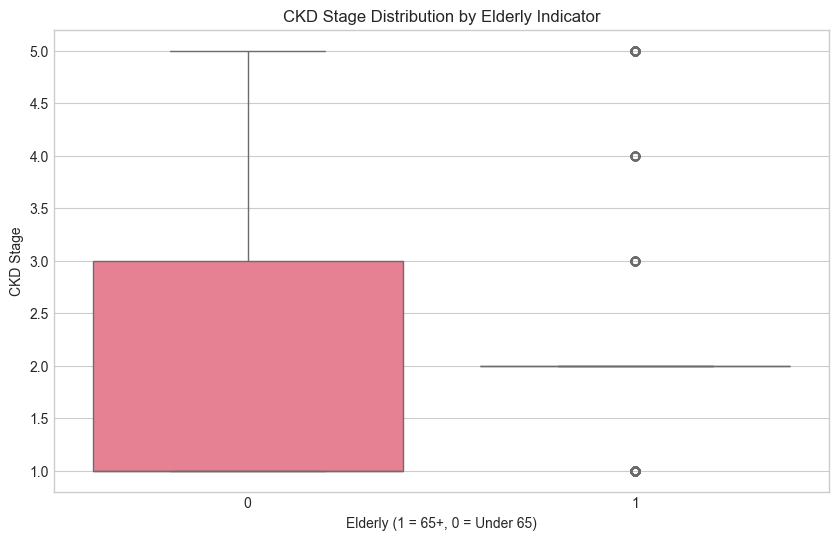

In [52]:
# YOUR ADDITIONAL EDA CODE HERE
# Add as many cells as you need - don't be limited by this template!

# Removed the Age Group prevous code, and added the Elderly section right here. 

# Create Elderly_Indicator if it doesn't exist yet
if "Elderly_Indicator" not in df.columns:
    df["Elderly_Indicator"] = (df["Age"] >= 65).astype(int)


# Then used the code below to show more

plt.figure(figsize=(10, 6))

sns.boxplot(x="Elderly_Indicator", y=TARGET, data=df)

plt.title("CKD Stage Distribution by Elderly Indicator")
plt.xlabel("Elderly (1 = 65+, 0 = Under 65)")
plt.ylabel("CKD Stage")
plt.show()





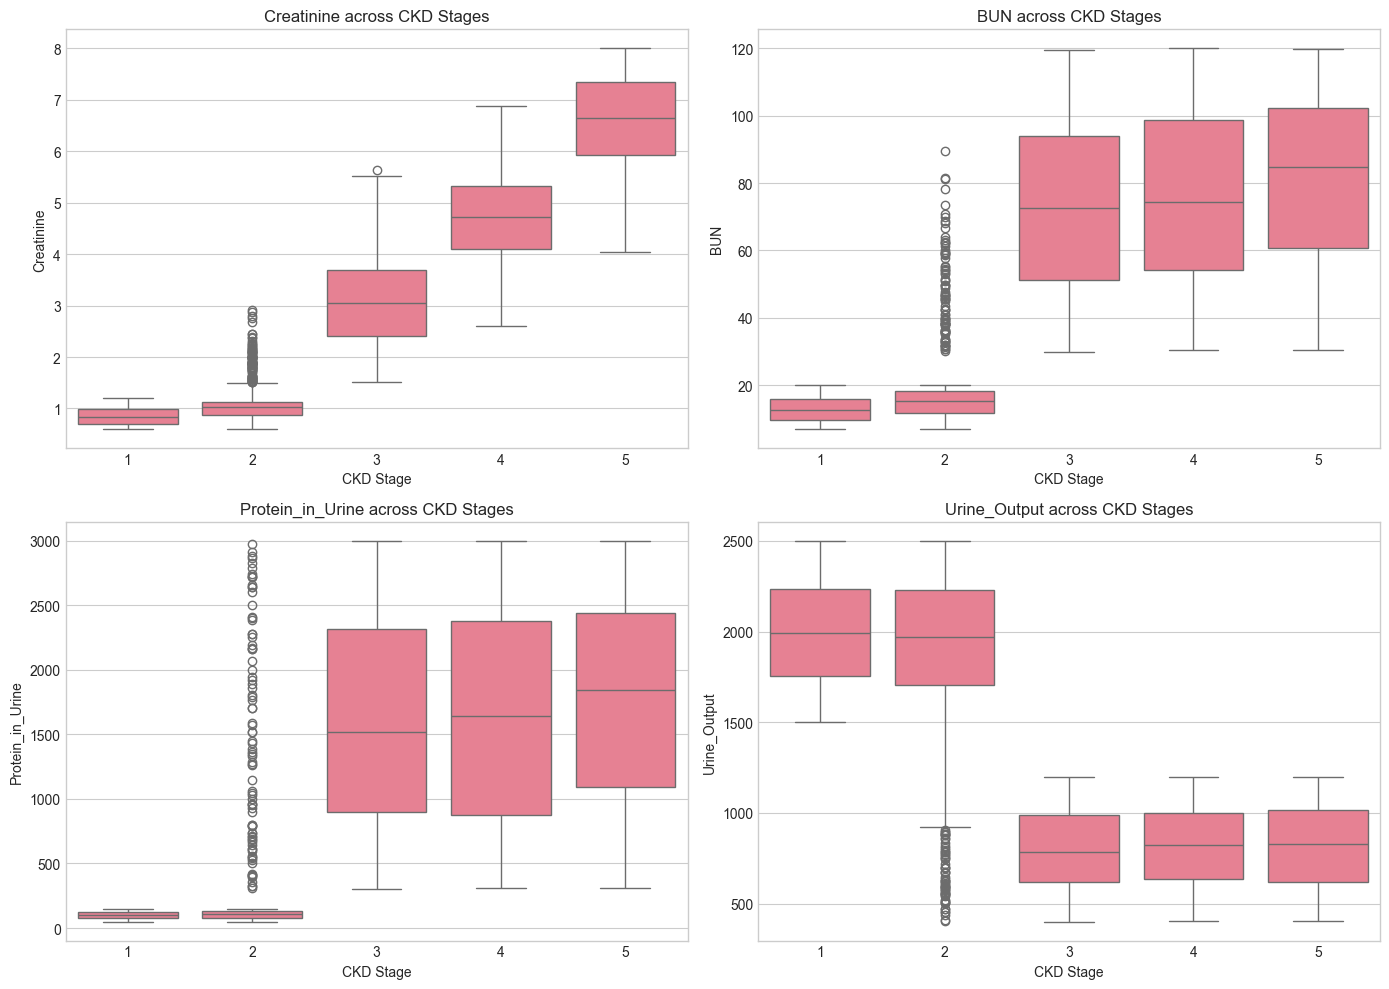

In [53]:
# More exploration...

# This one I used a lot of Google, took me awhile to think what to do for this one and some of the coding for it. A lot of errors at first. 

features_to_plot = ["Creatinine", "BUN", "Protein_in_Urine", "Urine_Output"]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feature in enumerate(features_to_plot):
    sns.boxplot(x=TARGET, y=feature, data=df, ax=axes[i])
    axes[i].set_title(f"{feature} across CKD Stages")

plt.tight_layout()
plt.show()




**What additional insights did you discover?**

[From the graphs above, I noticed creatitine, BUN, and protein in urine ioncrease as the CKD stage increase while uriin output decreases. This is very true, this is how it was for me during the stages from Stage 2 to 5 for me. It's showing what reflects from the kidney function as it worsens in each stage.]

### 4.7 EDA Insights Summary

*Summarize your key findings from the EDA.*

**Questions to answer:**
- Which features are most correlated with your target? 
- Which categorical features show the biggest differences in target?
- Are there any features that seem unimportant?
- Did you discover any interesting patterns or relationships?
- Are there any concerns about the data (outliers, skewness, etc.)?

**Your summary:**

[The EDA shows that CKD Stage is most strongly correlated with kidney function measurements, especially Creatinine, BUN, Protein in Urine, and Urine Output. Creatinine has the strongest positive relationship with CKD Stage, while Urine Output has a strong negative relationship. These trends were confirmed through both the correlation matrix and boxplots. Age, Diabetes, and Hypertension show weaker individual correlations but may still contribute when combined with other features. Overall, kidney function variables appear to be the most important predictors of CKD Stage.]

## Section 5: Data Cleaning

### 5.1 Decide What to Drop

Before cleaning, decide which columns to remove entirely.

In [54]:
# TODO: Create a copy of your dataframe for cleaning
#
# Why? We want to preserve the original data in case we need to go back.
# Never modify your original dataframe directly!
#
# Store in: df_clean

# YOUR CODE HERE:

# I already technically removed the columns I don't need earlier

# Create a copy of the dataframe for cleaning
df_clean = df.copy()


print(f"Starting shape: {df_clean.shape}")

Starting shape: (5000, 10)


In [55]:
# Identify columns to potentially drop
print("Columns to consider dropping:")
print("="*50)

# 1. High missing rate
high_missing = missing_summary[missing_summary['Missing %'] > 50].index.tolist()
print(f"\n1. >50% missing values: {high_missing}")

# 2. ID/index columns (no predictive value)
potential_ids = [col for col in df_clean.columns 
                 if 'id' in col.lower() or 'index' in col.lower() or 'url' in col.lower()]
print(f"\n2. Potential ID/URL columns: {potential_ids}")

# 3. High cardinality categorical (too many unique values)
high_cardinality = [col for col in categorical_cols if df_clean[col].nunique() > 100]
print(f"\n3. High cardinality (>100 unique): {high_cardinality}")

# 4. Low variance (same value in most rows)
low_variance = [col for col in df_clean.columns 
                if df_clean[col].value_counts(normalize=True).iloc[0] > 0.95]
print(f"\n4. Low variance (>95% same value): {low_variance}")

Columns to consider dropping:

1. >50% missing values: []

2. Potential ID/URL columns: []

3. High cardinality (>100 unique): []

4. Low variance (>95% same value): []


In [56]:
# Drop columns
# TODO: Decide which columns to drop based on the analysis above
# IMPORTANT: Don't just copy all suggestions - think about each one!

columns_to_drop = [
    # Add column names to drop here, e.g.:
    # 'id',
    # 'url',
]

if columns_to_drop:
    df_clean = df_clean.drop(columns=columns_to_drop)
    print(f"Dropped {len(columns_to_drop)} columns: {columns_to_drop}")
    print(f"New shape: {df_clean.shape}")
else:
    print("No columns dropped. Update the list above if needed.")

No columns dropped. Update the list above if needed.


**Explain which columns you dropped and why:**

[I already removed all the data leakage earlier in the section. I removed CKD_Status because I created a new column for my target (CKD Stage) which was created from GFR to show the specific stages (1-5) vs just a 'Yes' or 'No' that CKD_Status had. The 'Medication' column was removed because it contained a high percentage of missing values, which could have affected my analysis with this model. I wanted a simple and clean dataset for this model as my first one. In the real world, those feautures will have some weight to the target, but not a lot compared to features kept.]

### 5.2 Handle Duplicate Rows

In [57]:
# TODO: Remove duplicate rows from df_clean
#
# Steps:
# 1. Store the row count before: len(df_clean)
# 2. Use df_clean.drop_duplicates() to remove duplicates (assign back to df_clean)
# 3. Store the row count after
# 4. Print how many duplicates were removed

# YOUR CODE HERE:

# This was expecting to be clean after testing this earlier in the 1st checkpoint

# Row count before removing duplicates
rows_before = len(df_clean)

# Remove duplicate rows
df_clean = df_clean.drop_duplicates()

# Row count after removing duplicates
rows_after = len(df_clean)

# Print how many rows were removed
print(f"Rows before: {rows_before}")
print(f"Rows after: {rows_after}")
print(f"Duplicates removed: {rows_before - rows_after}")



Rows before: 5000
Rows after: 5000
Duplicates removed: 0


### 5.3 Handle Missing Values

In [58]:
# Check missing values in cleaned dataframe
print("Missing values before handling:")
missing_now = df_clean.isnull().sum()
missing_now = missing_now[missing_now > 0].sort_values(ascending=False)
print(missing_now)

Missing values before handling:
Series([], dtype: int64)


In [ ]:
# Handle missing values
# TODO: Add your missing value handling code here
# 
# STRATEGIES:
# - Numerical columns: use median (robust to outliers) or mean
# - Categorical columns: use mode or 'Unknown'
# - Drop rows if missing target variable
#
# Examples:
# df_clean['column'] = df_clean['column'].fillna(df_clean['column'].median())
# df_clean['column'] = df_clean['column'].fillna('Unknown')
# df_clean = df_clean.dropna(subset=[TARGET])  # Don't predict with missing target!

# YOUR CODE HERE:

#### I am not sure what to do here, I didn't have any missing values, the only category with it was Medication column which is why it was removed #####

In [59]:
# Verify missing values are handled
remaining_missing = df_clean.isnull().sum().sum()
print(f"Missing values after cleaning: {remaining_missing}")

if remaining_missing > 0:
    print("\n⚠️ Still have missing values in:")
    print(df_clean.isnull().sum()[df_clean.isnull().sum() > 0])

Missing values after cleaning: 0


**Explain your missing value strategy:**

[I don't know what to explain as I got lucky with the only column with a high percentage that was missing values was removed which was 'Medication'.]

### 5.4 Handle Outliers (if needed)

In [60]:
# Check for outliers using IQR method
def find_outliers_iqr(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    n_outliers = len(data[(data[column] < lower_bound) | (data[column] > upper_bound)])
    return n_outliers, lower_bound, upper_bound

# Get current numerical columns
current_numerical = df_clean.select_dtypes(include=[np.number]).columns.tolist()

print("Outlier analysis:")
print("="*60)
for col in current_numerical:
    n_outliers, lower, upper = find_outliers_iqr(df_clean, col)
    if n_outliers > 0:
        pct = n_outliers / len(df_clean) * 100
        print(f"{col}: {n_outliers:,} outliers ({pct:.1f}%) | bounds: [{lower:.2f}, {upper:.2f}]")

Outlier analysis:
Creatinine: 842 outliers (16.8%) | bounds: [-1.24, 4.21]
BUN: 559 outliers (11.2%) | bounds: [-32.54, 84.54]
Age: 15 outliers (0.3%) | bounds: [10.83, 89.12]
Protein_in_Urine: 861 outliers (17.2%) | bounds: [-673.41, 1345.53]
Elderly_Indicator: 769 outliers (15.4%) | bounds: [0.00, 0.00]


In [ ]:
# Handle outliers (if needed)
# TODO: Add your outlier handling code here if needed
#
# STRATEGIES:
# - Remove rows with outliers (be careful - losing data)
# - Cap/clip values at bounds
# - Keep them (if they're valid data points)
#
# Examples:
# df_clean = df_clean[df_clean['price'] > 0]  # Remove invalid prices
# df_clean = df_clean[df_clean['price'] < 500000]  # Remove extreme prices
# df_clean['column'] = df_clean['column'].clip(lower=0, upper=upper_bound)

# YOUR CODE HERE:

#### I didn't remove outliers because extreme lab results can be real in patients with severe CKD, and explained further below ####

**Explain your outlier handling strategy (or why you kept them):**

[The outliers creatinine, BUN, and protein in urine were kept because they likely represent patients with more severe measurements rather than data errors. That can happen as when I was stage 2, I had a high amount of protein in my urine when I was 10 years old, this is the first indication to the doctor that I may have CKD at the time before further testings. However, high amount didn't mean I was CKD Stage 5. Removing these outliers could remove important information, especially for a doctor, so I wanted to keep it for this model.]

### 5.5 Data Type Corrections

In [61]:
# Check current data types
print("Current data types:")
print(df_clean.dtypes)

Current data types:
Creatinine           float64
BUN                  float64
Urine_Output         float64
Diabetes               int64
Hypertension           int64
Age                  float64
Protein_in_Urine     float64
Water_Intake         float64
CKD Stage              int64
Elderly_Indicator      int64
dtype: object


In [62]:
# Fix any data type issues
# TODO: Add your data type corrections here if needed
#
# Examples:
# df_clean['year'] = df_clean['year'].astype(int)
# df_clean['date_column'] = pd.to_datetime(df_clean['date_column'])
# df_clean['category'] = df_clean['category'].astype('category')

# YOUR CODE HERE:

# No fixing of any data types, it was all correct, so just did a quick print for this

print("All data types are appropriate. No corrections needed.")


All data types are appropriate. No corrections needed.


## Section 6: Feature Engineering

Feature engineering is where you can really add value! The sections below cover common techniques, but feel free to go beyond these basics.

### 6.1 Create New Features (if applicable)

**Common feature engineering techniques:**
- **Ratios/interactions:** Combine existing features (e.g., price per square foot)
- **Log transforms:** Reduce skewness in highly skewed features
- **Binning:** Convert continuous variables to categories
- **Text features:** Extract length, word counts, etc. from text
- **Domain-specific:** Features that make sense for your specific problem

Think about what would help YOUR specific prediction problem!

In [ ]:
# Create new features
# TODO: Add your feature engineering code here
#
# Examples:
# df_clean['price_per_sqft'] = df_clean['price'] / df_clean['sqft']
# df_clean['log_price'] = np.log1p(df_clean['price'])
# df_clean['age'] = 2026 - df_clean['year']

# YOUR CODE HERE:

#### Nothing needs to be done here to create any new features ####

**Explain your new features:**

[I didn't create any additonal features because the existing features already represent meaningful clioncial information, a lot of these represent different biological processes with our body.]

### 6.2 Encode Categorical Variables

In [63]:
# TODO: Identify categorical columns that need encoding
#
# Steps:
# 1. Get categorical columns using select_dtypes(include=['object', 'category'])
# 2. For each column, print:
#    - Column name
#    - Number of unique values: .nunique()
#    - Recommendation: "one-hot encoding" if <= 10 unique, else "consider label encoding or dropping"
#
# Store in: cat_cols

# YOUR CODE HERE:

# This I had to google this one to do a one hot encoding

cat_cols = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()

print("Categorical columns:", cat_cols)
print("Number of categorical columns:", len(cat_cols))



Categorical columns: []
Number of categorical columns: 0


In [ ]:
# Encode categorical variables
# TODO: Add your encoding code here
#
# STRATEGIES:
# - One-hot encoding: for low cardinality (< 10 unique values)
# - Label encoding: for ordinal data or high cardinality
# - Target encoding: advanced technique (be careful of data leakage)
#
# Examples:
# One-hot encoding:
# df_clean = pd.get_dummies(df_clean, columns=['category_col'], drop_first=True)
#
# Label encoding:
# from sklearn.preprocessing import LabelEncoder
# le = LabelEncoder()
# df_clean['encoded_col'] = le.fit_transform(df_clean['category_col'])

# YOUR CODE HERE:

# I didn't want to encode anything

**Explain your encoding strategy:**

[The only categorical column identified was 'Age_Group', but that was removed earlier.]

### 6.3 Additional Feature Engineering (Your Choice!)

Every dataset has unique opportunities for feature engineering. What else makes sense for YOUR data?

**Think about:**
- What domain knowledge can you apply?
- Are there any feature interactions that might be predictive?
- Can you create meaningful groups or categories?
- Would polynomial features help capture non-linear relationships?

In [64]:
# YOUR ADDITIONAL FEATURE ENGINEERING CODE HERE
# Add as many cells as you need!


# Comorbidity Count (Diabetes + Hypertension)
df_clean['Comorbidity_Count'] = df_clean['Diabetes'] + df_clean['Hypertension']

# BUN to Creatinine Ratio
df_clean['BUN_Creatinine_Ratio'] = df_clean['BUN'] / df_clean['Creatinine']

# Elderly Indicator (Age 65+)
df_clean['Elderly_Indicator'] = (df_clean['Age'] >= 65).astype(int)

# Checking the new columns created

print(df_clean.columns)


Index(['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age',
       'Protein_in_Urine', 'Water_Intake', 'CKD Stage', 'Elderly_Indicator',
       'Comorbidity_Count', 'BUN_Creatinine_Ratio'],
      dtype='object')


In [67]:


print(df_clean.columns.tolist())

['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'CKD Stage', 'Elderly_Indicator', 'Comorbidity_Count', 'BUN_Creatinine_Ratio']


**Explain your additional feature engineering:**

[I created additional features using medical reasoning. Comorbidity_Count combines diabetes and hypertension to reflect overall health risk. BUN_Creatinine_Ratio was added because this ratio is commonly used in kidney assessments. Elderly_Indicator identifies patients 65 and older, since age is associated with CKD risk. These features may help the model better capture relationships that are not obvious from individual variables alone.]

### 6.4 Feature Scaling (Preparation)

We'll do actual scaling in the modeling notebook, but let's check which features might need it.

In [68]:
# TODO: Identify numerical features and check their ranges
#
# Steps:
# 1. Get numerical columns from df_clean (excluding TARGET)
# 2. For each column, print the min, max, and range
#
# This helps you understand if features need scaling (different scales = need scaling)
#
# Store in: numerical_features

# YOUR CODE HERE:

# Get numerical columns while excluding the target
numerical_features = df_clean.select_dtypes(include=['number']).columns.tolist()

# Remove target column if it exists in the list
if TARGET in numerical_features:
    numerical_features.remove(TARGET)

print("Numerical features to check:")
print(numerical_features)

print("\nFeature ranges:")
print("-" * 40)

# Print min, max, and range for each numerical column
for col in numerical_features:
    min_val = df_clean[col].min()
    max_val = df_clean[col].max()
    value_range = max_val - min_val

    print(f"{col}: min={min_val:.2f}, max={max_val:.2f}, range={value_range:.2f}")


Numerical features to check:
['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'Elderly_Indicator', 'Comorbidity_Count', 'BUN_Creatinine_Ratio']

Feature ranges:
----------------------------------------
Creatinine: min=0.60, max=8.00, range=7.40
BUN: min=7.01, max=119.93, range=112.92
Urine_Output: min=400.50, max=2499.94, range=2099.44
Diabetes: min=0.00, max=1.00, range=1.00
Hypertension: min=0.00, max=1.00, range=1.00
Age: min=18.00, max=90.00, range=72.00
Protein_in_Urine: min=50.01, max=2997.72, range=2947.71
Water_Intake: min=1.00, max=4.00, range=3.00
Elderly_Indicator: min=0.00, max=1.00, range=1.00
Comorbidity_Count: min=0.00, max=2.00, range=2.00
BUN_Creatinine_Ratio: min=3.90, max=78.75, range=74.85


### 6.5 Final Sanity Checks

In [70]:
# Final data quality checks before saving
print("="*60)
print("FINAL DATA QUALITY CHECKS")
print("="*60)

print(f"\n1. Shape: {df_clean.shape[0]:,} rows, {df_clean.shape[1]} columns")
print(f"   (Started with {df.shape[0]:,} rows, {df.shape[1]} columns)")

print(f"\n2. Missing values: {df_clean.isnull().sum().sum()}")

print(f"\n3. Duplicate rows: {df_clean.duplicated().sum()}")

print(f"\n4. Target variable '{TARGET}':")
print(f"   - Min: {df_clean[TARGET].min():.2f}")
print(f"   - Max: {df_clean[TARGET].max():.2f}")
print(f"   - Mean: {df_clean[TARGET].mean():.2f}")

# Check for data leakage red flags
print(f"\n5. Data types:")
print(f"   - Numerical: {len(df_clean.select_dtypes(include=[np.number]).columns)}")
print(f"   - Categorical: {len(df_clean.select_dtypes(include=['object', 'category']).columns)}")

remaining_cats = df_clean.select_dtypes(include=['object', 'category']).columns.tolist()
if remaining_cats:
    print(f"\n⚠️ Still have categorical columns: {remaining_cats}")
    print("   Make sure these are encoded before modeling!")
else:
    print("\n✓ All features are numerical. Ready for modeling!")

FINAL DATA QUALITY CHECKS

1. Shape: 5,000 rows, 12 columns
   (Started with 5,000 rows, 10 columns)

2. Missing values: 0

3. Duplicate rows: 0

4. Target variable 'CKD Stage':
   - Min: 1.00
   - Max: 5.00
   - Mean: 2.07

5. Data types:
   - Numerical: 12
   - Categorical: 0

✓ All features are numerical. Ready for modeling!


### 6.6 Save Processed Data

In [71]:
# Final check of cleaned data
print("Final cleaned dataset:")
print(f"Shape: {df_clean.shape}")
print(f"\nColumns ({len(df_clean.columns)}):")
print(df_clean.columns.tolist())
print(f"\nData types:")
print(df_clean.dtypes)

Final cleaned dataset:
Shape: (5000, 12)

Columns (12):
['Creatinine', 'BUN', 'Urine_Output', 'Diabetes', 'Hypertension', 'Age', 'Protein_in_Urine', 'Water_Intake', 'CKD Stage', 'Elderly_Indicator', 'Comorbidity_Count', 'BUN_Creatinine_Ratio']

Data types:
Creatinine              float64
BUN                     float64
Urine_Output            float64
Diabetes                  int64
Hypertension              int64
Age                     float64
Protein_in_Urine        float64
Water_Intake            float64
CKD Stage                 int64
Elderly_Indicator         int64
Comorbidity_Count         int64
BUN_Creatinine_Ratio    float64
dtype: object


In [72]:
# Save cleaned data
df_clean.to_csv('../data/processed/cleaned_data.csv', index=False)
print("✓ Cleaned data saved to ../data/processed/cleaned_data.csv")

✓ Cleaned data saved to ../data/processed/cleaned_data.csv


### 6.7 Feature Engineering Summary

*Summarize all the data cleaning and feature engineering you performed.*

**Checklist:**
- [ ] Columns dropped (with justification)
- [ ] Duplicate rows removed
- [ ] Missing values handled
- [ ] Outliers addressed (or documented why not)
- [ ] Data types corrected
- [ ] New features created (if applicable)
- [ ] Categorical variables encoded
- [ ] Data saved to processed folder

**Summary of changes:**

[During the data cleaning process, I removed columns that could cause data leakage or were not useful for modeling, including GFR, CKD_Status, Age Group, and Medication. Missing values and duplicate rows were checked, and none were found in the cleaned dataset. Outliers were reviewed using the IQR method; while some extreme values were identified in medical measurements, they were retained because they represent realistic clinical variability rather than data errors. All remaining features were confirmed to have appropriate numerical data types for modeling.]

**Final feature list for modeling:**

[Comorbidity Count was added to combine Diabetes and Hypertension into a single risk measure as these are two big factors that can impact CKD in general. BUN_Creatinine_Ratio was created to capture a clinically meaningful relationship between kidney functions. Elderly_Indicator was added to represent patients aged 65 and older because any elderly CKD patient is a high risk. Finally, I have a cleaned dataset that can help predict the severity of CKD.]

---

## ✅ Checkpoint 2 Submission Instructions

**Congratulations!** You've completed Checkpoint 2 (EDA, Data Cleaning, and Feature Engineering).

### Step 1: Save This Notebook
- File → Save (or Ctrl+S / Cmd+S)

### Step 2: Commit to GitHub

```bash
# Stage your changes
git add notebooks/01_problem_statement_and_eda.ipynb
git add data/processed/

# Commit with a meaningful message
git commit -m "Complete Checkpoint 2: EDA, data cleaning, and feature engineering"

# Push to GitHub
git push
```

### Step 3: Submit to Canvas
1. Go to the Checkpoint 2 assignment on Canvas
2. Submit the link to your GitHub repository

---

## Next Steps

You're ready to move on to **Notebook 02: Regression Model**!

In that notebook, you'll:
1. Load your cleaned data
2. Split into train/test sets
3. Build and evaluate regression models
4. Save your best model

---